# Task 4.2 — Analyzing VAE Performance

In this notebook, we perform post-training analysis of the VAE:
1. **Latent Space Visualization** — Plot encoder $\mu_\phi(x)$ for all MNIST test images, colour-coded by digit. Observe whether the VAE organises the 2D latent space into meaningful digit clusters.
2. **Reconstruction Quality** — Pass test images through encoder → reparameterize → decoder and compare original vs. reconstructed. Include per-pixel error maps and per-digit MSE analysis.
3. **Generation from Prior** — Sample $z \sim \mathcal{N}(0, I)$ and decode to generate novel handwritten digits.
4. **Latent Manifold Grid** — Sweep $z_1, z_2$ on a 2D grid to visualize continuous digit transitions.
5. **Latent Interpolation** — Linear interpolation between two digits in latent space.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from task4_vae.src.model import VAE
from task4_vae.src.analyze import (
    plot_latent_space,
    plot_latent_space_with_centroids,
    plot_reconstructions,
    plot_per_digit_reconstructions,
    sample_prior,
    plot_latent_manifold_grid,
    plot_latent_interpolation,
    compute_reconstruction_mse_per_digit
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


In [2]:
# Load trained VAE
LATENT_DIM = 2
vae = VAE(input_dim=784, hidden_dim=400, latent_dim=LATENT_DIM)

ckpt_path = '../results/checkpoints/vae_mnist.pth'
if os.path.exists(ckpt_path):
    vae.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    print(f'Loaded trained VAE from {ckpt_path}')
else:
    print(f'WARNING: Checkpoint not found at {ckpt_path}. Run notebook 1 first!')

vae.to(device)
vae.eval()

# Load MNIST test set
transform = transforms.ToTensor()
test_dataset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
print(f'MNIST test set: {len(test_dataset)} images')

Loaded trained VAE from ../results/checkpoints/vae_mnist.pth
MNIST test set: 10000 images


---
## 2a. Latent Space Visualization
Plot encoder mean $\mu_\phi(x)$ for all 10,000 test images in the 2D latent space, colour-coded by digit label.

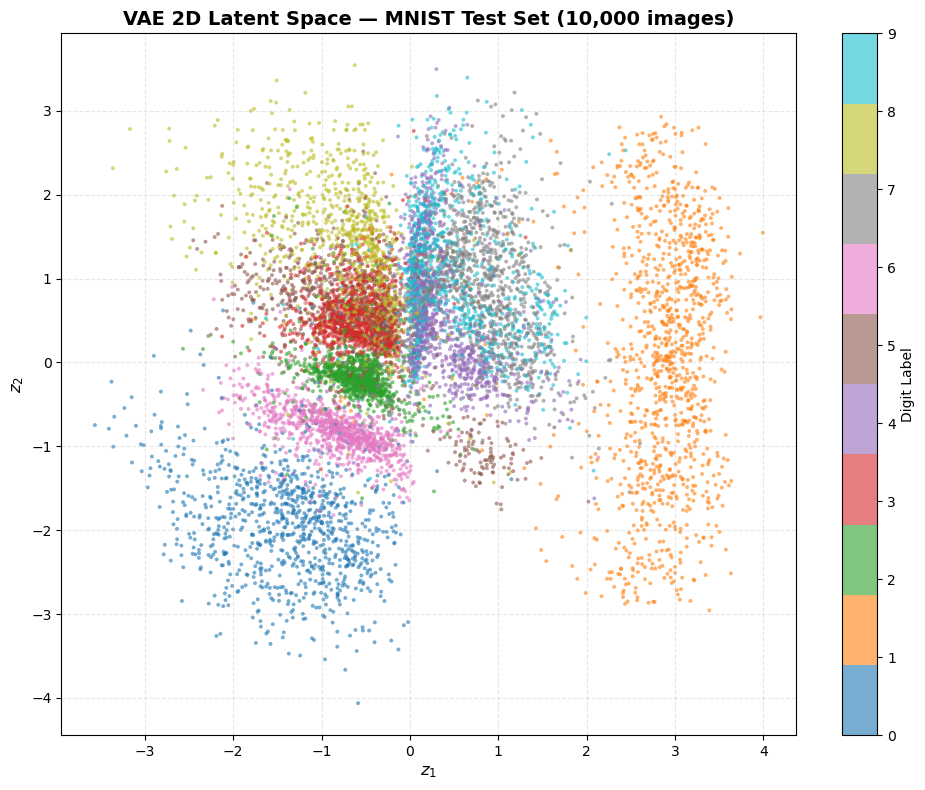

(array([[ 0.87233675,  1.0420034 ],
        [-0.45246926, -0.12964442],
        [ 3.0364804 , -0.43001845],
        ...,
        [ 1.2212709 ,  0.10140831],
        [ 0.66402525, -0.9986036 ],
        [-1.022236  , -0.81959987]], shape=(10000, 2), dtype=float32),
 array([7, 2, 1, ..., 4, 5, 6], shape=(10000,)))

In [3]:
os.makedirs('../results/figures', exist_ok=True)

plot_latent_space(
    vae, test_loader, device=device,
    save_path='../results/figures/latent_space.png',
    title='VAE 2D Latent Space — MNIST Test Set (10,000 images)'
)

### Latent Space with Per-Digit Centroids
Same visualization with class centroid annotations (★) to identify digit cluster positions.

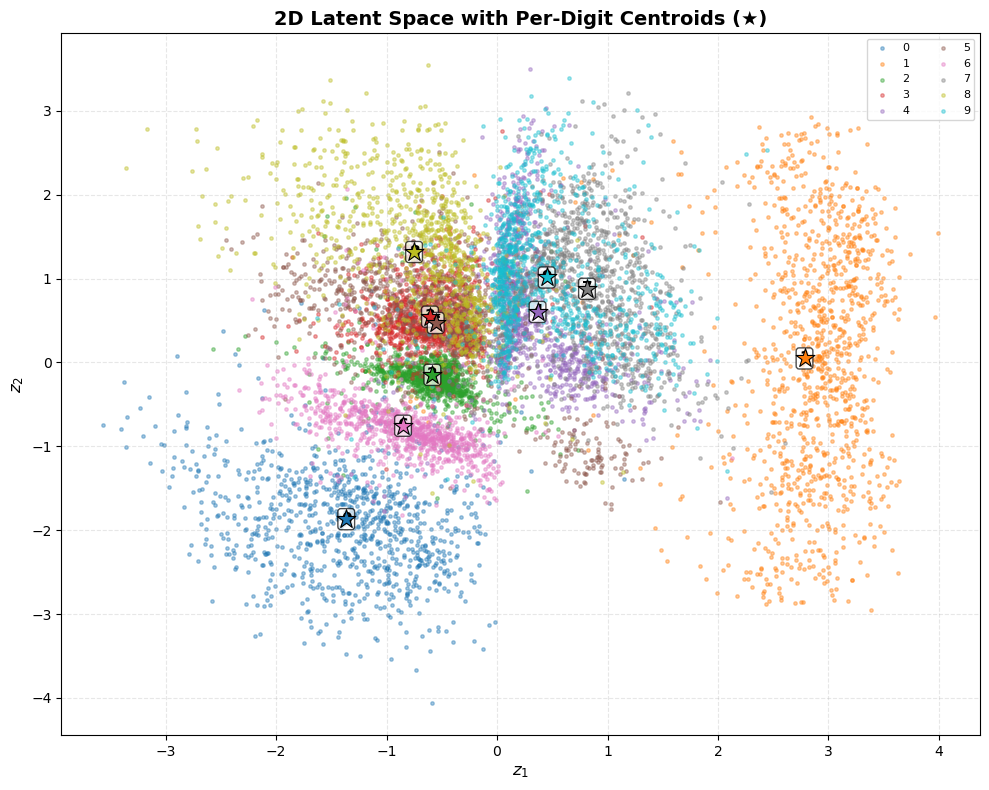

In [4]:
plot_latent_space_with_centroids(
    vae, test_loader, device=device,
    save_path='../results/figures/latent_space_centroids.png'
)

---
## 2b. Reconstruction Quality
Pass test images through the full VAE pipeline (encode → reparameterize → decode) and compare originals vs. reconstructions.

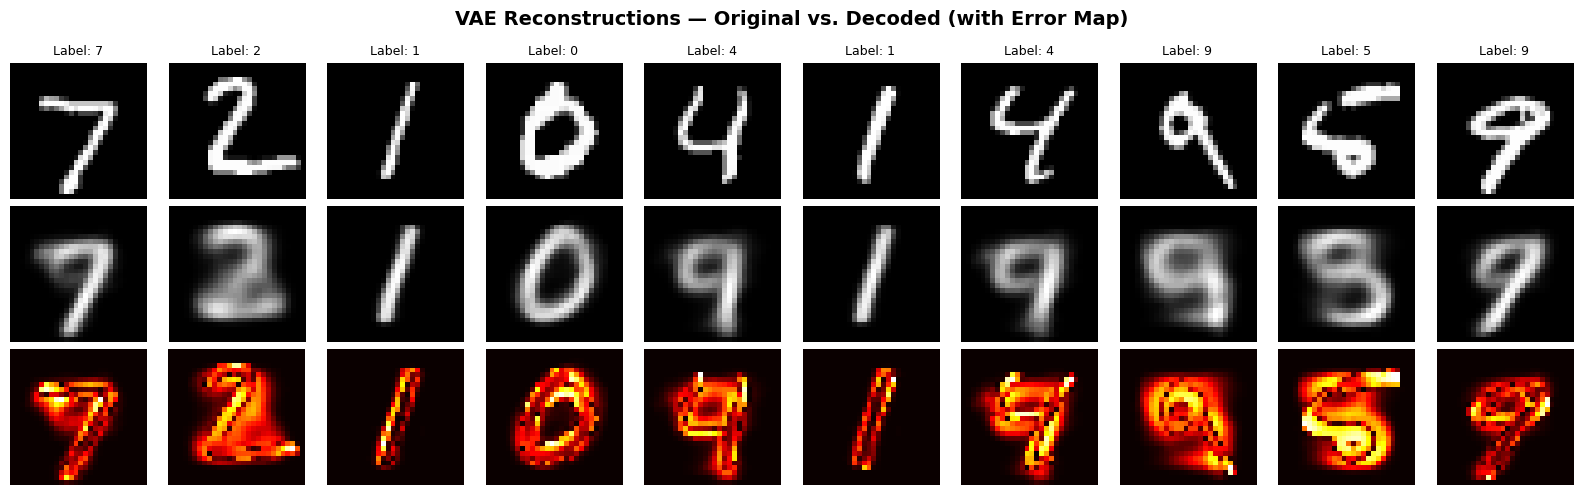

In [5]:
plot_reconstructions(
    vae, test_loader, device=device, num_images=10,
    save_path='../results/figures/reconstructions.png',
    title='VAE Reconstructions — Original vs. Decoded (with Error Map)'
)

### Per-Digit Reconstruction (Digits 0–9)
One representative image per class to assess which digits reconstruct best/worst.

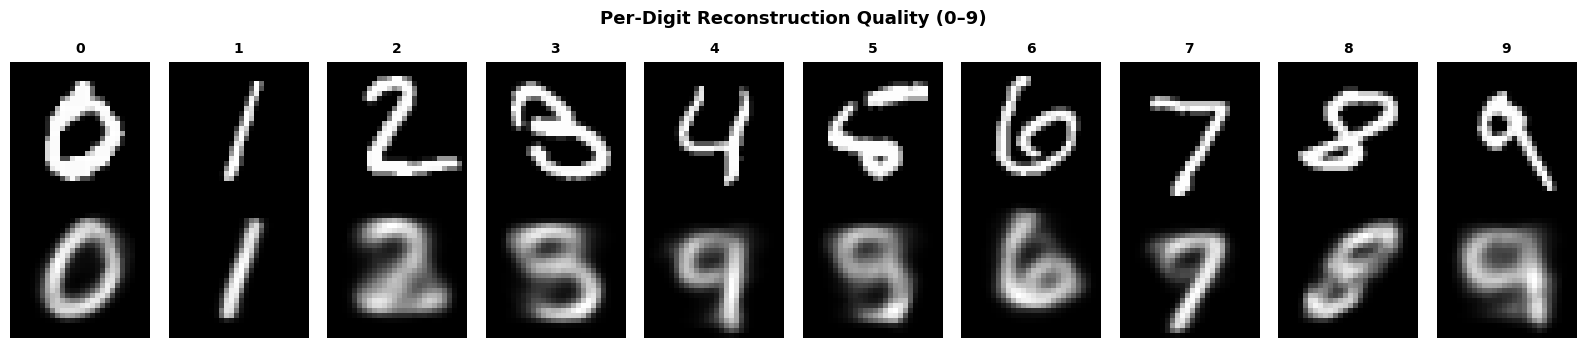

In [6]:
plot_per_digit_reconstructions(
    vae, test_loader, device=device,
    save_path='../results/figures/per_digit_reconstructions.png'
)

### Per-Digit Reconstruction MSE
Quantifying which digit classes the VAE reconstructs best vs. worst.

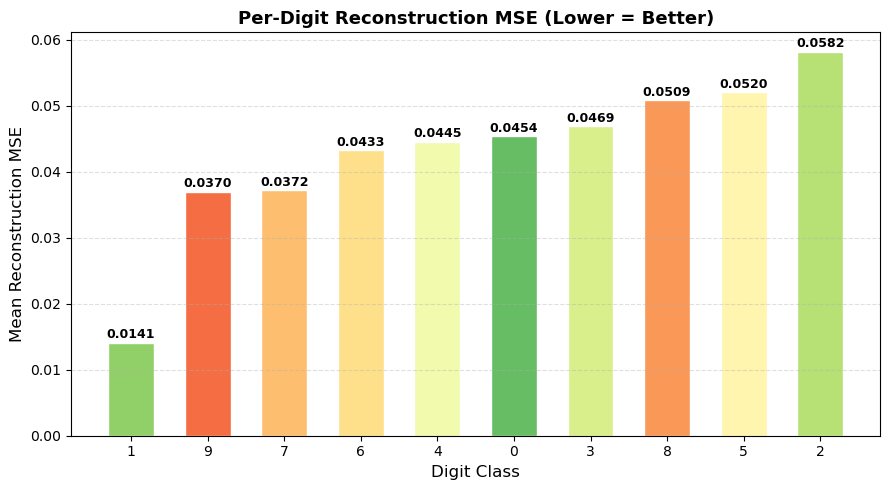

Best reconstructed digit:  1 (MSE: 0.0141)
Worst reconstructed digit: 2 (MSE: 0.0582)


In [7]:
digit_mse = compute_reconstruction_mse_per_digit(vae, test_loader, device=device)

fig, ax = plt.subplots(figsize=(9, 5))
digits = list(range(10))
mse_vals = [digit_mse[d] for d in digits]
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 10))

# Sort by MSE for visual clarity
sorted_pairs = sorted(zip(digits, mse_vals), key=lambda x: x[1])
sorted_digits, sorted_mses = zip(*sorted_pairs)
sorted_colors = [colors[d] for d in sorted_digits]

bars = ax.bar([str(d) for d in sorted_digits], sorted_mses, color=sorted_colors, width=0.6, edgecolor='white')
for bar, val in zip(bars, sorted_mses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Digit Class', fontsize=12)
ax.set_ylabel('Mean Reconstruction MSE', fontsize=12)
ax.set_title('Per-Digit Reconstruction MSE (Lower = Better)', fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../results/figures/per_digit_mse.png', bbox_inches='tight', dpi=300)
plt.show()

best_digit = sorted_digits[0]
worst_digit = sorted_digits[-1]
print(f'Best reconstructed digit:  {best_digit} (MSE: {digit_mse[best_digit]:.4f})')
print(f'Worst reconstructed digit: {worst_digit} (MSE: {digit_mse[worst_digit]:.4f})')

---
## 2c. Generation of New Samples from Prior
Sampling $z \sim \mathcal{N}(0, I)$ and decoding to produce novel handwritten digit images.

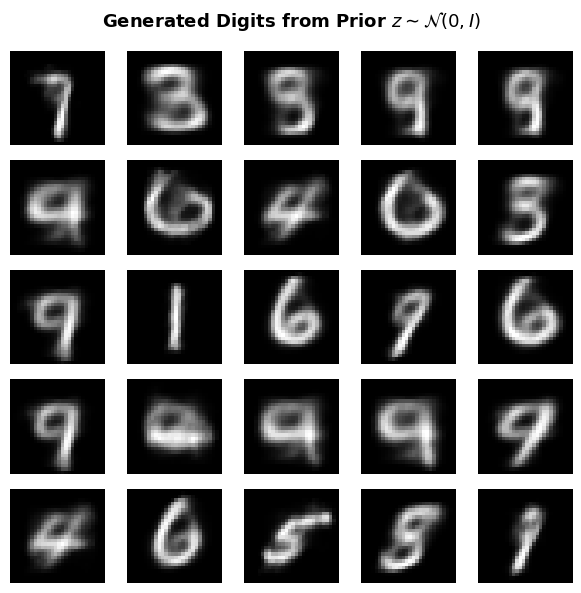

In [8]:
sample_prior(
    vae, num_samples=25, latent_dim=LATENT_DIM, device=device,
    save_path='../results/figures/prior_samples.png',
    title='Generated Digits from Prior $z \\sim \\mathcal{N}(0, I)$'
)

### Larger Sample Grid (64 samples)

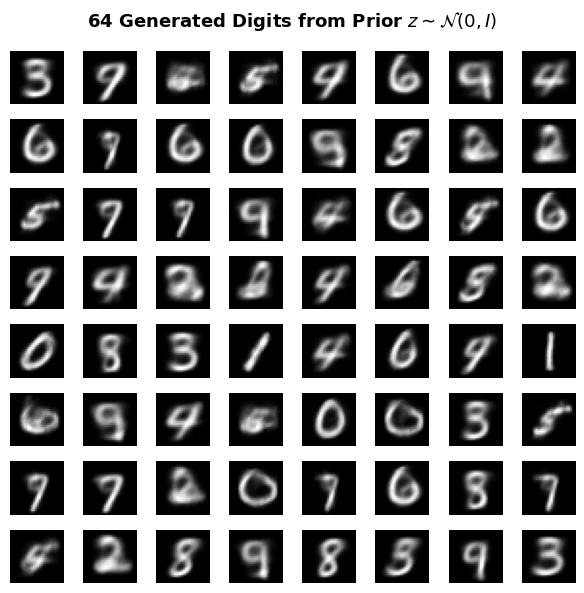

In [9]:
sample_prior(
    vae, num_samples=64, latent_dim=LATENT_DIM, device=device,
    save_path='../results/figures/prior_samples_large.png',
    title='64 Generated Digits from Prior $z \\sim \\mathcal{N}(0, I)$'
)

---
## Latent Manifold Grid
Sweeping $z_1$ and $z_2$ on a 20×20 grid (using inverse CDF of $\mathcal{N}(0,1)$) to visualise continuous digit transitions across the entire latent space.

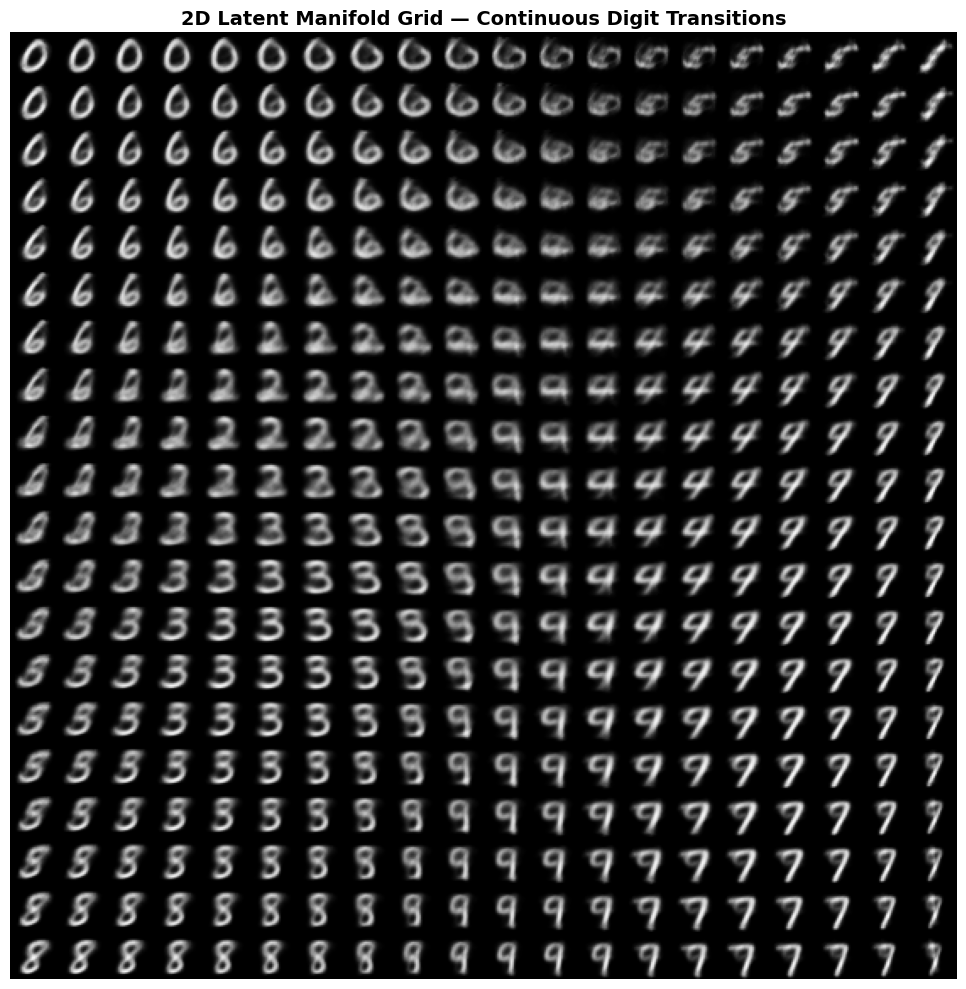

In [10]:
plot_latent_manifold_grid(
    vae, n=20, device=device,
    save_path='../results/figures/latent_manifold_grid.png',
    title='2D Latent Manifold Grid — Continuous Digit Transitions'
)

---
## Latent Space Interpolation
Linear interpolation between two test digits in latent space, showing smooth morphing.

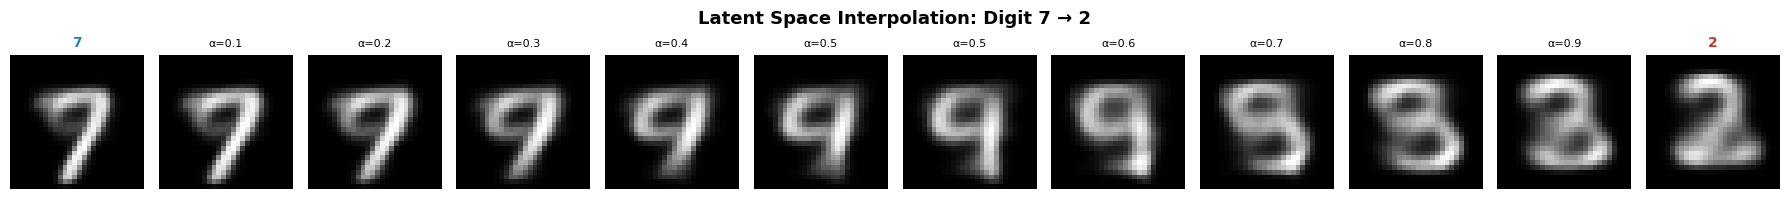

In [11]:
plot_latent_interpolation(
    vae, test_loader, device=device, num_steps=12,
    save_path='../results/figures/latent_interpolation.png'
)

### Multiple Interpolation Pairs
Interpolating between different digit pairs to demonstrate generative continuity.

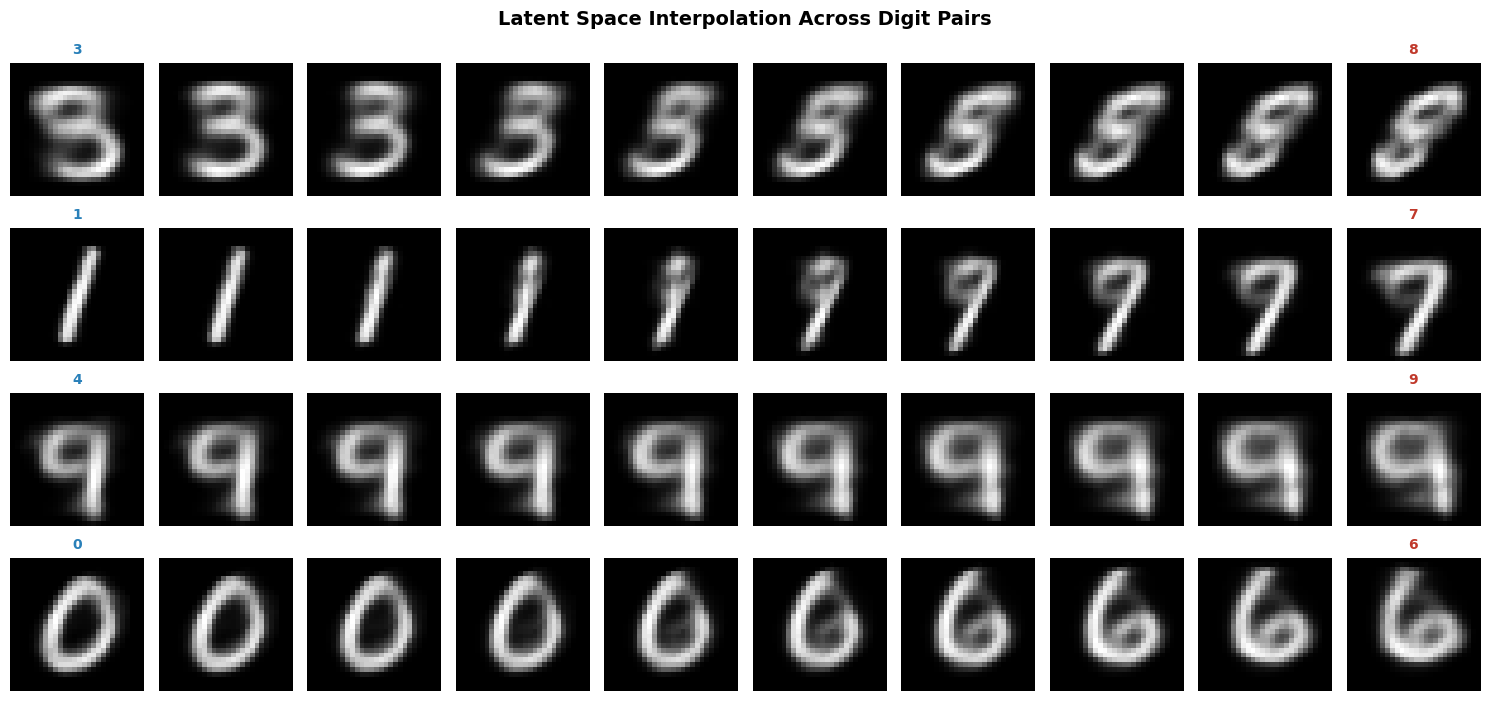

In [12]:
# Custom interpolation between specific digit pairs
vae.eval()

# Collect one example per digit
digit_examples = {}
for data, targets in test_loader:
    for img, label in zip(data, targets):
        l = label.item()
        if l not in digit_examples:
            digit_examples[l] = img
        if len(digit_examples) == 10:
            break
    if len(digit_examples) == 10:
        break

pairs = [(3, 8), (1, 7), (4, 9), (0, 6)]
num_steps = 10

fig, axes = plt.subplots(len(pairs), num_steps, figsize=(num_steps * 1.5, len(pairs) * 1.8))

with torch.no_grad():
    for row, (d1, d2) in enumerate(pairs):
        img1 = digit_examples[d1].unsqueeze(0).to(device)
        img2 = digit_examples[d2].unsqueeze(0).to(device)
        mu1, _ = vae.encode(img1.view(-1, 784))
        mu2, _ = vae.encode(img2.view(-1, 784))

        for col, alpha in enumerate(np.linspace(0, 1, num_steps)):
            z_interp = (1 - alpha) * mu1 + alpha * mu2
            decoded = vae.decode(z_interp).view(28, 28).cpu().numpy()
            axes[row, col].imshow(decoded, cmap='gray')
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_title(str(d1), fontsize=10, fontweight='bold', color='#2980b9')
            elif col == num_steps - 1:
                axes[row, col].set_title(str(d2), fontsize=10, fontweight='bold', color='#c0392b')

        axes[row, 0].set_ylabel(f'{d1} → {d2}', fontsize=10, fontweight='bold')

fig.suptitle('Latent Space Interpolation Across Digit Pairs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/multi_interpolation.png', bbox_inches='tight', dpi=300)
plt.show()